Dataset Preview:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies    

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21652\3389628238.py:34: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns



Final Train/Test Split Shapes:
(5625, 29) (1407, 29)


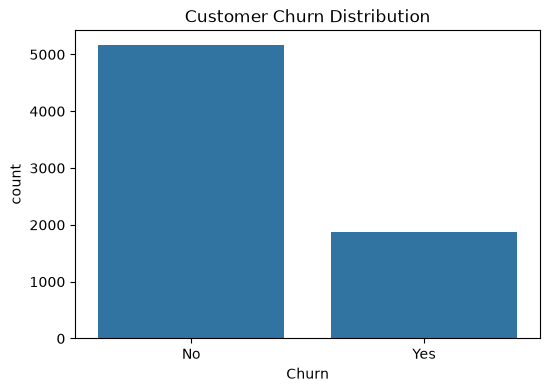

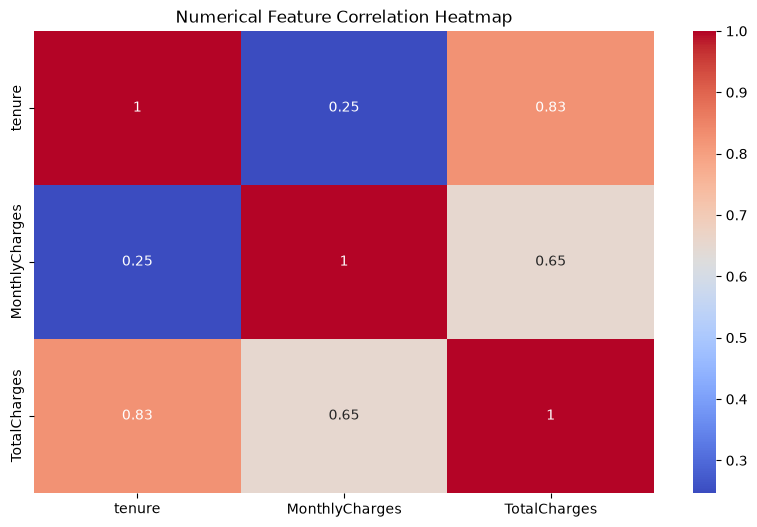

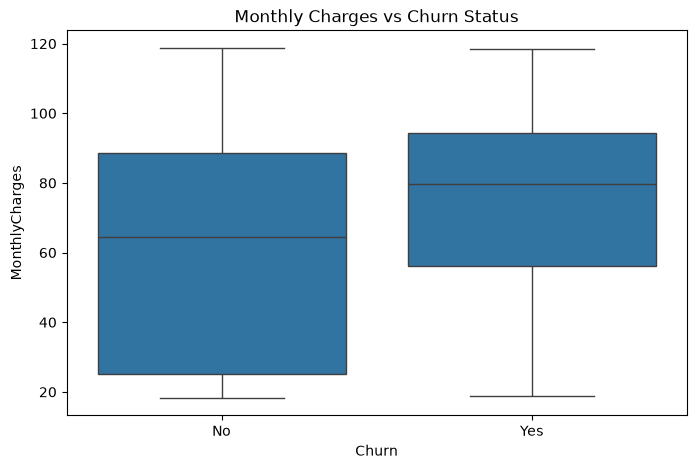

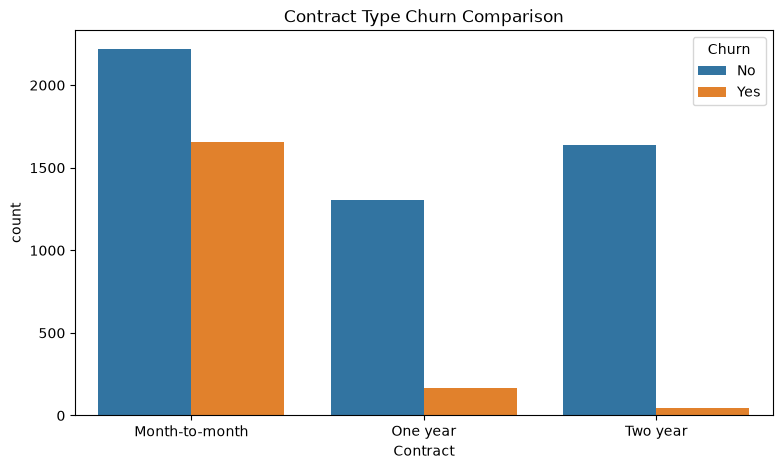


Best Hyperparameters: {'max_depth': 10, 'n_estimators': 200}

===== 模型评估指标 =====
准确率 Accuracy: 0.79
精确率 Precision: 0.64
召回率 Recall: 0.48
F1 Score: 0.55
AUC-ROC: 0.83

混淆矩阵：
[[930 103]
 [193 181]]


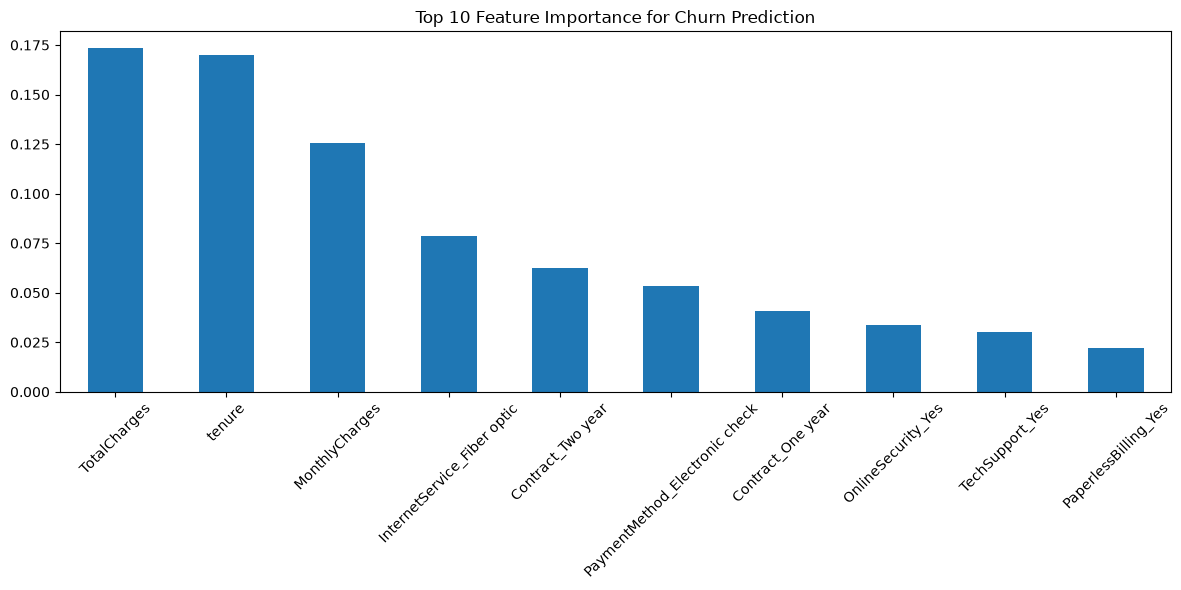


Model preprocessing files saved successfully.


In [2]:
# Library Imports
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# ---------------------- Task 2a Data Preparation ----------------------
# Load dataset
df = pd.read_csv("telco_customer_churn.csv")
print("Dataset Preview:")
print(df.head())
print("\nDataset Summary Info:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())
# Identify data quality issues
print("\nMissing Values Count:")
print(df.isnull().sum())
print("\nDuplicate Rows Count:", df.duplicated().sum())
# Data cleaning & preprocessing
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])
df = df.drop('customerID', axis=1)
# Split features and target
X = df.drop('Churn', axis=1)
y = df['Churn'].map({'Yes':1, 'No':0})
# Encode categorical variables
cat_cols = X.select_dtypes(include=['object']).columns
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_cats = encoder.fit_transform(X[cat_cols])
encoded_df = pd.DataFrame(encoded_cats, columns=encoder.get_feature_names_out(cat_cols))
# Scale numerical features
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
scaled_nums = scaler.fit_transform(X[num_cols])
scaled_df = pd.DataFrame(scaled_nums, columns=num_cols)
# Combine processed features
X_processed = pd.concat([scaled_df, encoded_df], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)
print("\nFinal Train/Test Split Shapes:")
print(X_train.shape, X_test.shape)

# ---------------------- Task 2b Exploratory Data Analysis ----------------------
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()
plt.figure(figsize=(10,6))
sns.heatmap(df[['tenure','MonthlyCharges','TotalCharges']].corr(), annot=True, cmap='coolwarm')
plt.title("Numerical Feature Correlation Heatmap")
plt.show()
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn Status")
plt.show()
plt.figure(figsize=(9,5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract Type Churn Comparison")
plt.show()

# ---------------------- Task 2c Predictive Model Development ----------------------
# Random Forest Classifier with Grid Search
rf = RandomForestClassifier(random_state=42)
params = {    
'n_estimators': [100,200],    
'max_depth': [10,20,None]
}
grid = GridSearchCV(rf, params, cv=5)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
print("\nBest Hyperparameters:", grid.best_params_)
# Model Prediction & Evaluation
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:,1]

print("\n===== 模型评估指标 =====")
print(f"准确率 Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"精确率 Precision: {precision_score(y_test, y_pred):.2f}")
print(f"召回率 Recall: {recall_score(y_test, y_pred):.2f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.2f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.2f}")
print("\n混淆矩阵：")
print(confusion_matrix(y_test, y_pred))

# 绘制Top10特征重要性图
feature_importance = pd.Series(best_model.feature_importances_, index=X_processed.columns).sort_values(ascending=False)
plt.figure(figsize=(12,6))
feature_importance.head(10).plot(kind='bar')
plt.title("Top 10 Feature Importance for Churn Prediction")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 保存模型、编码器、标准化器
joblib.dump(best_model, "churn_rf_model.joblib")
joblib.dump(encoder, "encoder.joblib")
joblib.dump(scaler, "scaler.joblib")
print("\nModel preprocessing files saved successfully.")